In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
dataset = pd.read_csv('forestfires.csv')

In [5]:
dataset

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [7]:
dataset.shape

(517, 13)

In [8]:
dataset.columns

Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='object')

In [9]:
dataset["area"].describe()

,area
count,517.000000
mean,12.847292
std,63.655818
min,0.000000
25%,0.000000
50%,0.520000
75%,6.570000
max,1090.840000


In [10]:
dataset.isnull().sum()


,0
X,0
Y,0
month,0
day,0
FFMC,0
DMC,0
DC,0
ISI,0
temp,0
RH,0


In [11]:
dataset.duplicated().sum()

np.int64(4)

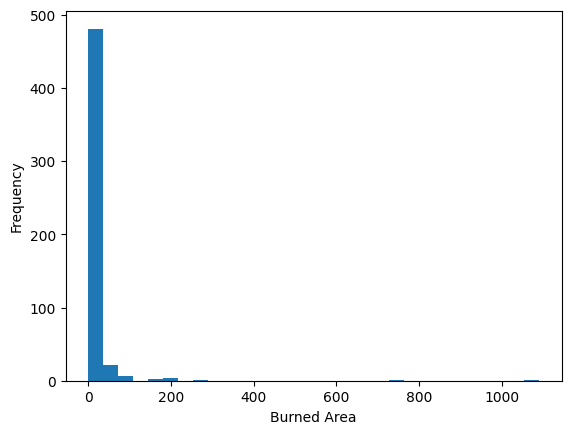

In [12]:
plt.hist(dataset["area"], bins= 30)
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.show()

In [13]:

dataset["area"] = np.log1p(dataset["area"])

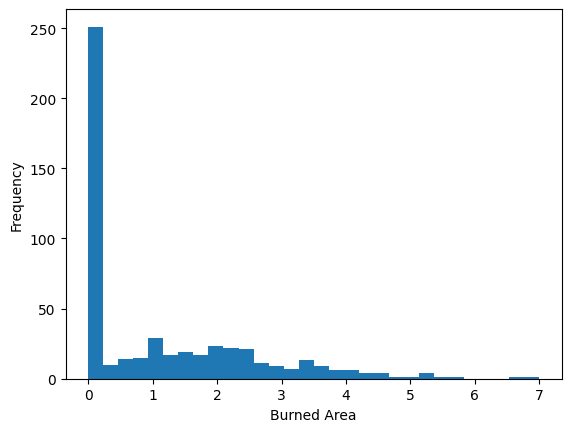

In [14]:
plt.hist(dataset["area"], bins= 30)
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.show()

In [15]:
X = dataset.drop("area", axis=1)
y = dataset["area"]



In [16]:

print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 42)

In [18]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['month', 'day'])
    ],
    remainder='passthrough'
)



In [20]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [21]:
X_train = ct.fit_transform(X_train)


In [22]:
X_test = ct.transform(X_test)

In [23]:
print(type(X_train))
print(type(X))

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [24]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = regressor.predict(X_test)

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

R2_lr = r2_score(y_test, y_pred)
MAE_lr = mean_absolute_error(y_test, y_pred)
RMSE_lr = root_mean_squared_error(y_test, y_pred)


In [28]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [29]:
y_pred_dt = regressor.predict(X_test)
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

R2_dt = r2_score(y_test, y_pred_dt)
MAE_dt  = mean_absolute_error(y_test, y_pred_dt)
RMSE_dt= root_mean_squared_error(y_test, y_pred_dt)



In [30]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [31]:
y_pred_rfr = regressor.predict(X_test)
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

R2_rr = r2_score(y_test, y_pred_rfr)
MAE_rr  = mean_absolute_error(y_test, y_pred_rfr)
RMSE_rr= root_mean_squared_error(y_test, y_pred_rfr)



In [32]:
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X_train_scaled, y_train)

y_pred_svr = regressor.predict(X_test_scaled)

In [33]:

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

R2_svr = r2_score(y_test, y_pred_svr)
MAE_svr  = mean_absolute_error(y_test, y_pred_svr)
RMSE_svr = root_mean_squared_error(y_test, y_pred_svr)


In [34]:
from sklearn.neighbors import KNeighborsRegressor

regressor = KNeighborsRegressor(n_neighbors=5)
regressor.fit(X_train_scaled, y_train)

y_pred_knn = regressor.predict(X_test_scaled)

In [35]:

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

R2_knn = r2_score(y_test, y_pred_knn)
MAE_knn  = mean_absolute_error(y_test, y_pred_knn)
RMSE_knn = root_mean_squared_error(y_test, y_pred_knn)

In [36]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVR (RBF)",
        "KNN"
    ],
    "R² Score": [
        R2_lr,
        R2_dt,
        R2_rr,
        R2_svr,
        R2_knn
    ],
    "MAE": [
        MAE_lr,
        MAE_dt,
        MAE_rr,
        MAE_svr,
        MAE_knn
    ],
    "RMSE": [
        RMSE_lr,
        RMSE_dt,
        RMSE_rr,
        RMSE_svr,
        RMSE_knn
    ]
})

results

,Model,R² Score,MAE,RMSE
0,Linear Regression,-0.026988,1.185917,1.463621
1,Decision Tree,-0.877860,1.380441,1.979145
2,Random Forest,-0.056486,1.201880,1.484492
3,SVR (RBF),-0.191172,1.150859,1.576280
4,KNN,-0.238214,1.239701,1.607103


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestRegressor(random_state=42)

# Hyperparameters to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10, 20]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Train all combinations
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [39]:
print("Best Cross Validation R²:")
print(grid_search.best_score_)

Best Cross Validation R²:
-0.021837379453681825


In [40]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [41]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

print("Training R²:", best_rf.score(X_train, y_train))
print("Testing R²:", best_rf.score(X_test, y_test))

Test R²: 4.553339321233807e-05
MAE: 1.18730410585726
RMSE: 1.4442292479318235
Training R²: 0.1405035829708967
Testing R²: 4.553339321233807e-05


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation R² Scores: [-0.12948438 -1.01982982 -0.04487816 -0.05228557 -0.03461557]
Mean R²: -0.25621869930503793
Standard Deviation: 0.38328188540006064


In [43]:
import joblib

joblib.dump(best_rf, "forest_fire_random_forest.pkl")
joblib.dump(ct, "preprocessor.pkl")

['preprocessor.pkl']

In [59]:
%%writefile app.py

import gradio as gr
import pandas as pd
import numpy as np
import joblib


model = joblib.load("forest_fire_random_forest.pkl")
preprocessor = joblib.load("preprocessor.pkl")




def predict_fire(
    X, Y,
    month, day,
    FFMC, DMC, DC, ISI,
    temp, RH, wind, rain
):

    # Create DataFrame
    input_data = pd.DataFrame({
        "X": [X],
        "Y": [Y],
        "month": [month],
        "day": [day],
        "FFMC": [FFMC],
        "DMC": [DMC],
        "DC": [DC],
        "ISI": [ISI],
        "temp": [temp],
        "RH": [RH],
        "wind": [wind],
        "rain": [rain]
    })

    # Apply preprocessing
    input_processed = preprocessor.transform(input_data)

    # Predict
    prediction = model.predict(input_processed)

    # Convert from log scale
    prediction = np.expm1(prediction)

    return f"""
### 🔥 Prediction Complete

**Estimated Burned Area:** **{prediction[0]:.2f} hectares**

> **Note:** This prediction is generated using a tuned Random Forest Regressor trained on the UCI Forest Fires dataset. The result is an estimate and should not be interpreted as an exact real-world burned area.
"""



examples = [
    [7, 5, "mar", "fri", 86.2, 26.2, 94.3, 5.1, 8.2, 51, 6.7, 0.0],
    [7, 4, "oct", "tue", 90.6, 35.4, 669.1, 6.7, 18.0, 33, 0.9, 0.0]
]




with gr.Blocks(theme=gr.themes.Soft(), title="Forest Fire Predictor") as demo:

    gr.Markdown("""
# 🌲 Forest Fire Burned Area Prediction

Predict the estimated burned area of a forest fire using meteorological conditions and fire weather indices.

### 🔍 Model Information

- 🌳 **Algorithm:** Random Forest Regressor
- ⚙️ **Hyperparameter Optimization:** GridSearchCV (5-Fold Cross Validation)
- 🔄 **Categorical Encoding:** One-Hot Encoding
- 📈 **Target Transformation:** Log1p
- 📊 **Dataset:** UCI Forest Fires Dataset
""")

    with gr.Row():

        with gr.Column():

            x = gr.Number(label="📍 X Coordinate")
            y = gr.Number(label="📍 Y Coordinate")

            month = gr.Dropdown(
                choices=[
                    "jan","feb","mar","apr","may","jun",
                    "jul","aug","sep","oct","nov","dec"
                ],
                label="📅 Month"
            )

            day = gr.Dropdown(
                choices=[
                    "mon","tue","wed","thu",
                    "fri","sat","sun"
                ],
                label="📅 Day"
            )

            ffmc = gr.Number(
                label="🔥 FFMC (Fine Fuel Moisture Code)"
            )

            dmc = gr.Number(
                label="🌿 DMC (Duff Moisture Code)"
            )

            dc = gr.Number(
                label="🌳 DC (Drought Code)"
            )

            isi = gr.Number(
                label="💨 ISI (Initial Spread Index)"
            )

        with gr.Column():

            temp = gr.Number(
                label="🌡️ Temperature (°C)"
            )

            rh = gr.Number(
                label="💧 Relative Humidity (%)"
            )

            wind = gr.Number(
                label="🌬️ Wind Speed (km/h)"
            )

            rain = gr.Number(
                label="🌧️ Rain (mm)"
            )

            output = gr.Markdown()

            predict_btn = gr.Button(
                "🔥 Predict Burned Area",
                variant="primary",
                size="lg"
            )

            clear_btn = gr.ClearButton()

    gr.Examples(
        examples=examples,
        inputs=[
            x, y,
            month, day,
            ffmc, dmc, dc, isi,
            temp, rh, wind, rain
        ]
    )

    predict_btn.click(
        fn=predict_fire,
        inputs=[
            x, y,
            month, day,
            ffmc, dmc, dc, isi,
            temp, rh, wind, rain
        ],
        outputs=output
    )



demo.launch()

Overwriting app.py


In [58]:
%run app.py

/content/app.py:74: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Forest Fire Predictor") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://336b1e6cff8af9639f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<Figure size 640x480 with 0 Axes>